In [1]:
## reload submodule
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

In [3]:
data = pd.read_csv("./data/_^spx_with_leverage.csv", index_col=0, parse_dates=[0], sep=",")
data

,open,high,low,close,volume,signal,leverage
date,,,,,,,
2023-01-03,3853.290039,3878.459961,3794.330078,3824.139893,3959140000,1,1.0
2023-01-04,3840.360107,3873.159912,3815.770020,3852.969971,4414080000,1,1.0
2023-01-05,3839.739990,3839.739990,3802.419922,3808.100098,3893450000,1,1.0
2023-01-06,3823.370117,3906.189941,3809.560059,3895.080078,3923560000,1,1.0
2023-01-09,3910.820068,3950.570068,3890.419922,3892.090088,4311770000,1,1.0
...,...,...,...,...,...,...,...
2025-04-01,5597.529785,5650.569824,5558.520020,5633.069824,4434500000,-1,2.0
2025-04-02,5580.759766,5695.310059,5571.479980,5670.970215,4243830000,-1,2.0
2025-04-03,5492.740234,5499.529785,5390.830078,5396.520020,7210470000,-1,2.0


In [4]:
from qfin.backtester.runners import bt_signal_change

backtest_params = {
    "initial_balance": 10000,
    "default_entry_value": 1,
    "default_entry_value_max": 10000,
    "commission": 0.001,
    "trailing_enabled": True,
    "trailing_activation_pct": 2,
    "trailing_distance_pct": 2,
    "trailing_min_step_pct": 1,
    "takeprofit_pct": 10,
    "stoploss_pct": 1,
    "breakeven_pct": 2,
}

# running a predefined strategy
bt = bt_signal_change(data, leverage_column="leverage", **backtest_params)

In [5]:
stats = bt.stats()
stats


Start                     2023-01-03 00:00:00
End                       2025-04-07 00:00:00
Duration                    825 days 00:00:00
Exposure Time [%]                   53.968254
Equity Start                            10000
Equity Peak                             31501
Equity Final                            31501
Equity Return [%]                      215.01
Balance Start                           10000
Balance Peak                            31501
Balance Final                           31501
Balance Return [%]                     215.01
Gross Return [%]                       102.69
Total Commissions                         677
Return (Ann.) [%]                   66.674357
Volatility (Ann.) [%]               28.035259
CAGR [%]                            66.196463
Sharpe Ratio                         2.199885
Sortino Ratio                        9.256811
Calmar Ratio                         8.152774
Max. Drawdown [%]                   -8.178119
Avg. Drawdown [%]                 

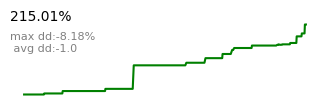

In [6]:
bt.thumbnail()

In [7]:
bt.trades()

,is_long,leverage,entry_value,entry_price,entry_bar,entry_commission,entry_time,exit_value,exit_price,exit_commission,exit_bar,exit_time,pnl,return_pct,exit_reason
0,False,1.0,9990.0,4179.759766,21,10.0,2023-02-02,10321.185565,4045.639893,10.321186,41,2023-03-03,331.185565,0.033152,trailing
1,True,1.5,14985.0,3861.590088,46,15.0,2023-03-10,15739.373838,4055.989990,15.739374,78,2023-04-26,754.373838,0.050342,trailing
2,False,3.5,34965.0,4588.959961,143,35.0,2023-07-31,35675.008663,4497.629883,35.675009,164,2023-08-29,710.008663,0.020306,trailing
3,True,7.0,69930.0,4117.370117,206,70.0,2023-10-27,77233.347053,4547.379883,77.233347,222,2023-11-20,7303.347053,0.104438,takeprofit
4,False,1.4,13986.0,5254.350098,310,14.0,2024-03-28,14794.430851,4967.229980,14.794431,325,2024-04-19,808.430851,0.057803,manual
5,True,1.4,13986.0,4967.229980,325,14.0,2024-04-19,15410.720826,5473.229980,15.410721,365,2024-06-17,1424.720826,0.101868,takeprofit
6,False,1.4,13986.0,5667.200195,384,14.0,2024-07-16,15282.764640,5186.330078,15.282765,398,2024-08-05,1296.764640,0.092719,manual
7,True,1.4,13986.0,5186.330078,398,14.0,2024-08-05,15232.065805,5648.399902,15.232066,417,2024-08-30,1246.065805,0.089094,manual
8,False,1.4,13986.0,5648.399902,417,14.0,2024-08-30,14606.580512,5408.419922,14.606581,421,2024-09-06,620.580512,0.044372,manual
9,True,1.4,13986.0,5408.419922,421,14.0,2024-09-06,14754.110736,5705.450195,14.754111,460,2024-10-31,768.110736,0.054920,trailing


In [ ]:
bt.plot(title="Backtest")